# Healthcare Dataset — EDA & ML Training

End-to-end notebook for the LuxDevHQ pre-internship healthcare ML project.

**Sections:**
1. Data Loading
2. Target Variable Distribution
3. Age Distribution by Test Result
4. Billing Amount Distribution
5. Categorical Feature Breakdowns
6. Summary Statistics
7. Data Preprocessing & Feature Engineering
8. Model Training — RandomForestClassifier
9. Model Evaluation
10. Feature Importance
11. Save Model Artifacts

## 1. Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os

matplotlib.rcParams['figure.dpi'] = 100

kaggle_path = '/kaggle/input/datasets/prasad22/healthcare-dataset/healthcare_dataset.csv'
local_path  = '../data/cleaned_healthcare.csv'

if os.path.exists(kaggle_path):
    df = pd.read_csv(kaggle_path)
    print(f'Loaded from Kaggle path')
else:
    df = pd.read_csv(local_path)
    print(f'Loaded from local path')

print(f'Shape: {df.shape}')
df.head()

Loaded from local path
Shape: (54966, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,Ab+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal


## 2. Target Variable Distribution

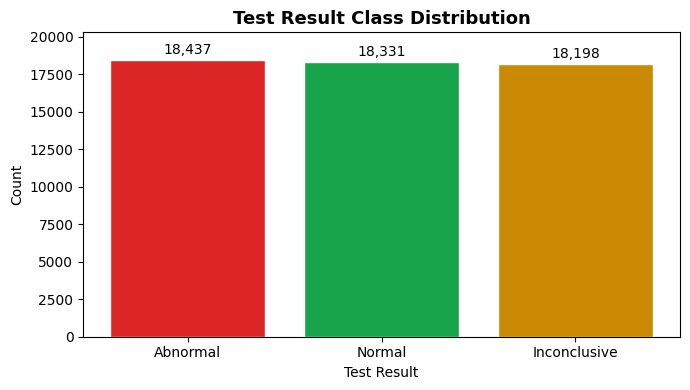

Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64


In [2]:
counts = df['Test Results'].value_counts()
color_map = {'Normal': '#16a34a', 'Abnormal': '#dc2626', 'Inconclusive': '#ca8a04'}
colors = [color_map.get(x, '#3b82f6') for x in counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(counts.values) * 0.02),
            f'{val:,}', ha='center', fontsize=10)

ax.set_title('Test Result Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Test Result')
ax.margins(y=0.1)
plt.tight_layout()
plt.show()
print(counts)

## 3. Age Distribution by Test Result

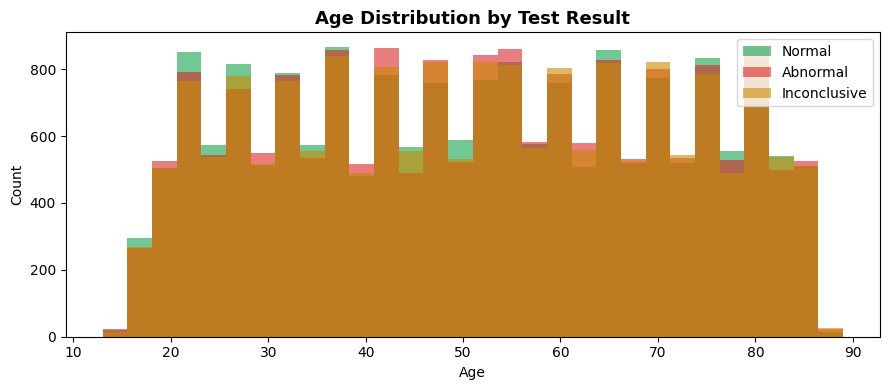

                count       mean        std   min   25%   50%   75%   max
Test Results                                                             
Abnormal      18437.0  51.640668  19.560542  13.0  35.0  52.0  68.0  89.0
Inconclusive  18198.0  51.659193  19.542602  13.0  35.0  52.0  68.0  89.0
Normal        18331.0  51.305984  19.712255  13.0  34.0  51.0  68.0  89.0


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color in zip(['Normal', 'Abnormal', 'Inconclusive'], ['#16a34a', '#dc2626', '#ca8a04']):
    subset = df[df['Test Results'] == label]['Age']
    ax.hist(subset, bins=30, alpha=0.6, label=label, color=color)

ax.set_title('Age Distribution by Test Result', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()
print(df.groupby('Test Results')['Age'].describe())

## 4. Billing Amount Distribution

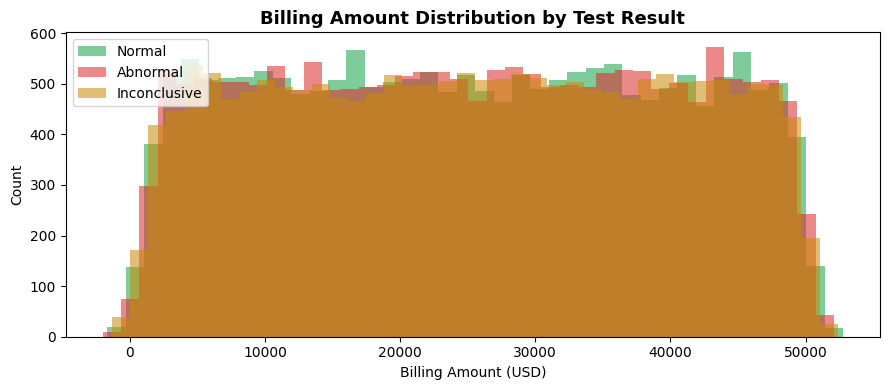

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color in zip(['Normal', 'Abnormal', 'Inconclusive'], ['#16a34a', '#dc2626', '#ca8a04']):
    subset = df[df['Test Results'] == label]['Billing Amount']
    ax.hist(subset, bins=40, alpha=0.55, label=label, color=color)

ax.set_title('Billing Amount Distribution by Test Result', fontsize=13, fontweight='bold')
ax.set_xlabel('Billing Amount (USD)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Categorical Feature Breakdowns

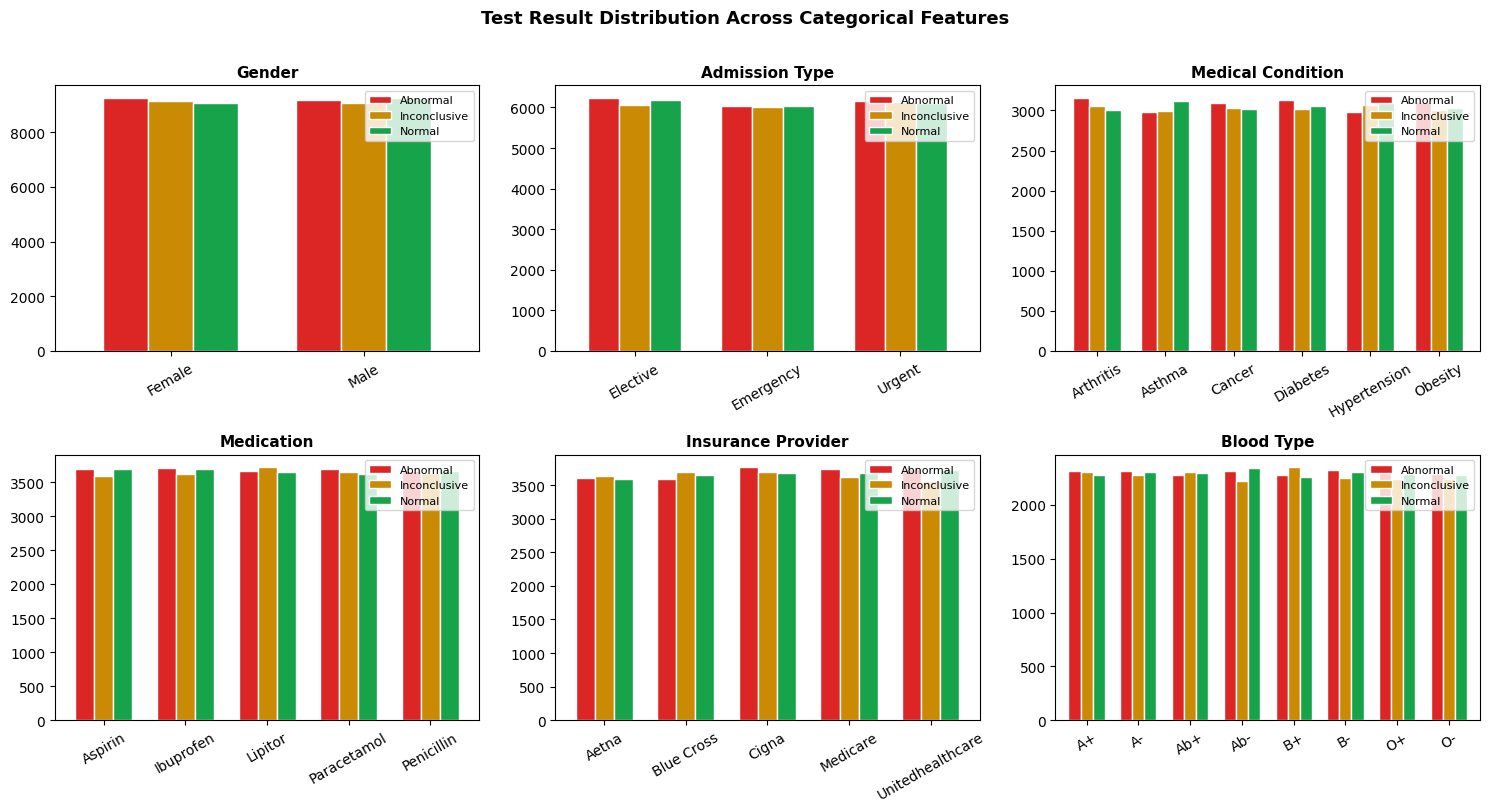

In [5]:
cat_cols = ['Gender', 'Admission Type', 'Medical Condition', 'Medication', 'Insurance Provider', 'Blood Type']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    pivot = df.groupby([col, 'Test Results']).size().unstack(fill_value=0)
    pivot.plot(kind='bar', ax=axes[i], color=['#dc2626', '#ca8a04', '#16a34a'], edgecolor='white', width=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

plt.suptitle('Test Result Distribution Across Categorical Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [6]:
print('=== Dataset Summary ===')
print(f'Total records : {len(df):,}')
print(f'Features      : {df.shape[1] - 1}')
print(f'Null values   : {df.isnull().sum().sum()}')
print()
print('=== Target Distribution ===')
for label, count in df['Test Results'].value_counts().items():
    print(f'  {label:15s}: {count:,}  ({count / len(df) * 100:.1f}%)')
print()
print('=== Numeric Feature Stats ===')
print(df[['Age', 'Billing Amount']].describe().round(2))

=== Dataset Summary ===
Total records : 54,966
Features      : 14
Null values   : 0

=== Target Distribution ===
  Abnormal       : 18,437  (33.5%)
  Normal         : 18,331  (33.3%)
  Inconclusive   : 18,198  (33.1%)

=== Numeric Feature Stats ===
            Age  Billing Amount
count  54966.00        54966.00
mean      51.54        25544.31
std       19.61        14208.41
min       13.00        -2008.49
25%       35.00        13243.72
50%       52.00        25542.75
75%       68.00        37819.86
max       89.00        52764.28


---
## 7. Data Preprocessing & Feature Engineering

**Features used (8 total):**
- Numeric: `Age`, `Billing Amount`
- Categorical: `Gender`, `Blood Type`, `Medical Condition`, `Insurance Provider`, `Admission Type`, `Medication`

**Target:** `Test Results` (Normal / Abnormal / Inconclusive)

Categorical columns are encoded with `LabelEncoder`; numeric columns are scaled with `StandardScaler`.

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_ml = df.copy()
df_ml.columns = [c.lower().replace(' ', '_') for c in df_ml.columns]

CATEGORICAL_FEATURES = ['gender', 'blood_type', 'medical_condition',
                         'insurance_provider', 'admission_type', 'medication']
NUMERIC_FEATURES     = ['age', 'billing_amount']
FEATURE_COLS         = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET_COL           = 'test_results'

label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_ml[TARGET_COL])
label_encoders[TARGET_COL] = target_encoder

scaler = StandardScaler()
df_ml[NUMERIC_FEATURES] = scaler.fit_transform(df_ml[NUMERIC_FEATURES])

X = df_ml[FEATURE_COLS].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Classes    : {list(target_encoder.classes_)}')
print(f'X_train    : {X_train.shape}')
print(f'X_test     : {X_test.shape}')
print(f'Features   : {FEATURE_COLS}')

Classes    : ['Abnormal', 'Inconclusive', 'Normal']
X_train    : (43972, 8)
X_test     : (10994, 8)
Features   : ['age', 'billing_amount', 'gender', 'blood_type', 'medical_condition', 'insurance_provider', 'admission_type', 'medication']


## 8. Model Training — RandomForestClassifier

Parameters match the production model in `ml/train.py`:
- `n_estimators=50`, `max_depth=15`, `min_samples_split=10`, `min_samples_leaf=5`
- Constrained to keep the serialised artifact under GitHub's 100 MB file size limit.

In [8]:
from sklearn.ensemble import RandomForestClassifier
import time

clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)

t0 = time.time()
clf.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'Training complete in {elapsed:.1f}s')
print(f'n_estimators : {clf.n_estimators}')
print(f'max_depth    : {clf.max_depth}')
print(f'n_features   : {clf.n_features_in_}')

Training complete in 1.1s
n_estimators : 50
max_depth    : 15
n_features   : 8


## 9. Model Evaluation

In [9]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, ConfusionMatrixDisplay
)

y_pred = clf.predict(X_test)
class_names = target_encoder.classes_

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names))
print(f'Accuracy      : {accuracy:.4f} ({accuracy*100:.1f}%)')
print(f'F1 (macro)    : {f1_macro:.4f}')
print(f'Baseline (random 3-class): 33.3%')

=== Classification Report ===
              precision    recall  f1-score   support

    Abnormal       0.38      0.39      0.38      3688
Inconclusive       0.37      0.37      0.37      3640
      Normal       0.38      0.38      0.38      3666

    accuracy                           0.38     10994
   macro avg       0.38      0.38      0.38     10994
weighted avg       0.38      0.38      0.38     10994

Accuracy      : 0.3771 (37.7%)
F1 (macro)    : 0.3771
Baseline (random 3-class): 33.3%


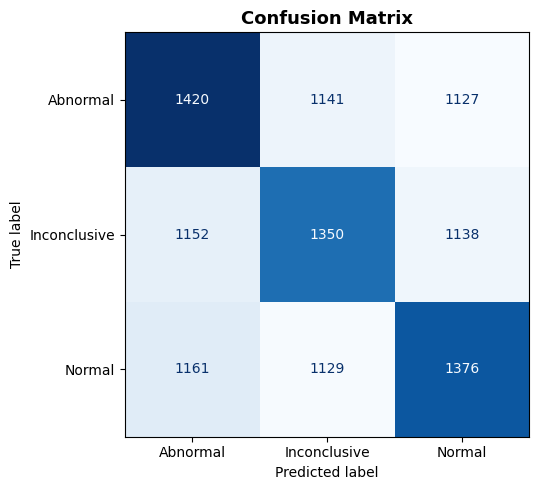

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Feature Importance

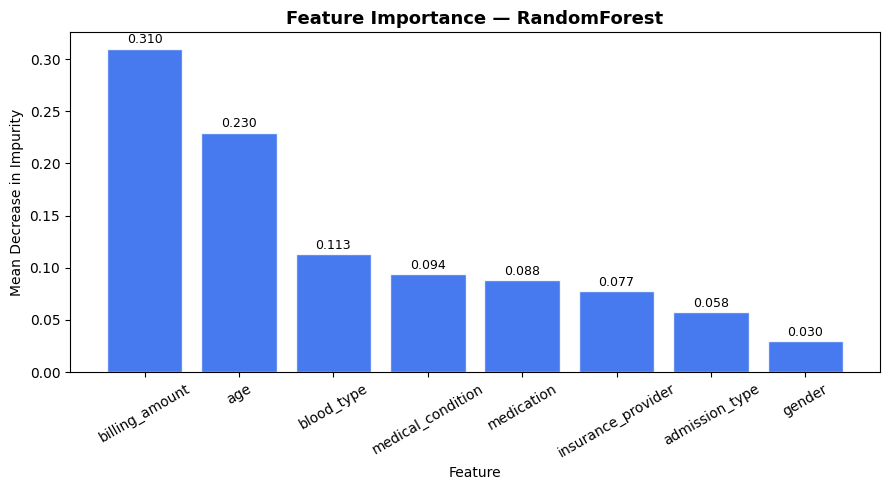


Ranked feature importances:
  billing_amount           : 0.3101
  age                      : 0.2296
  blood_type               : 0.1128
  medical_condition        : 0.0942
  medication               : 0.0884
  insurance_provider       : 0.0774
  admission_type           : 0.0576
  gender                   : 0.0300


In [11]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [FEATURE_COLS[i] for i in indices]
sorted_importances = importances[indices]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(sorted_features, sorted_importances,
              color='#2563eb', edgecolor='white', alpha=0.85)

for bar, val in zip(bars, sorted_importances):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Feature Importance — RandomForest', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Decrease in Impurity')
ax.set_xlabel('Feature')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('\nRanked feature importances:')
for feat, imp in zip(sorted_features, sorted_importances):
    print(f'  {feat:25s}: {imp:.4f}')

## 11. Save Model Artifacts

Saves `model.joblib` and `encoders.joblib` to `../models/` — the same paths used by the FastAPI production server.

In [12]:
import joblib
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

model_path    = models_dir / 'model.joblib'
encoders_path = models_dir / 'encoders.joblib'

joblib.dump(clf, model_path, compress=3)
joblib.dump({'label_encoders': label_encoders, 'scaler': scaler}, encoders_path)

model_size_mb = model_path.stat().st_size / (1024 * 1024)

print(f'model.joblib    saved → {model_path}  ({model_size_mb:.1f} MB)')
print(f'encoders.joblib saved → {encoders_path}')
print(f'\nFinal metrics:')
print(f'  Accuracy : {accuracy*100:.1f}%')
print(f'  F1 macro : {f1_macro:.4f}')
print(f'  Samples  : {len(df):,}')

model.joblib    saved → ..\models\model.joblib  (5.1 MB)
encoders.joblib saved → ..\models\encoders.joblib

Final metrics:
  Accuracy : 37.7%
  F1 macro : 0.3771
  Samples  : 54,966
